# 01 Data Understanding

This notebook documents the data-understanding phase for the AML graph-enhanced data mining project.

Main goals:
- Load IBM AMLworld `HI-Small_Trans.csv`.
- Inspect schema, class imbalance, timestamps, transaction fields, and graph structure.
- Create report-ready label-distribution and timeline artifacts.
- Keep the output aligned with the final project scope: transaction-level AML scoring using graph-enhanced machine learning.

In [1]:
from pathlib import Path
import sys

# Works whether the notebook is launched from repository root or from notebooks/.
CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
TABLES_DIR = REPORTS_DIR / "tables"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [PROCESSED_DIR, TABLES_DIR, FIGURES_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)


import pandas as pd
import matplotlib.pyplot as plt

from src.data.load_data import load_transactions
from src.features.graph_features import build_sample_graph, graph_summary

PROJECT_ROOT: /home/acer/dev/aml-graph-dm


## 1. Configuration

Use `NROWS = 2_000_000` to match the final experiment setup. Set `NROWS = None` only when you intentionally want to inspect the full HI-Small file.

In [2]:
DATASET_NAME = "HI-Small"
RAW_PATH = RAW_DIR / f"{DATASET_NAME}_Trans.csv"
NROWS = 2_000_000

if not RAW_PATH.exists():
    raise FileNotFoundError(
        f"Raw dataset not found: {RAW_PATH}\n"
        "Put HI-Small_Trans.csv inside data/raw/ before running this notebook."
    )

df = load_transactions(RAW_PATH, nrows=NROWS)
display(df.head())
print("Loaded shape:", df.shape)

,timestamp,from_bank,sender_account,to_bank,receiver_account,amount_received,receiving_currency,amount_paid,payment_currency,payment_format,is_laundering,sender_id,receiver_id
0,2022-09-01,220,813720AB1,220,813720AB1,5.234544,Bitcoin,5.234544,Bitcoin,Bitcoin,0,220_813720AB1,220_813720AB1
1,2022-09-01,1412,80E6B8060,1412,80E6B8060,21.100000,US Dollar,21.100000,US Dollar,Reinvestment,0,1412_80E6B8060,1412_80E6B8060
2,2022-09-01,10,803E2BBE0,27564,80E6C2430,2809.450000,US Dollar,2809.450000,US Dollar,Credit Card,0,10_803E2BBE0,27564_80E6C2430
3,2022-09-01,1047,80E6C2FA0,1047,80E6C2FA0,6461.310000,US Dollar,6461.310000,US Dollar,Reinvestment,0,1047_80E6C2FA0,1047_80E6C2FA0
4,2022-09-01,18049,811F7E630,18049,811F7E630,13.070000,Euro,13.070000,Euro,Reinvestment,0,18049_811F7E630,18049_811F7E630


Loaded shape: (2000000, 13)


## 2. Schema and target distribution

In [3]:
print("Schema:")
display(df.dtypes)

print("\nTarget counts:")
label_counts = df["is_laundering"].value_counts(dropna=False).sort_index()
display(label_counts)

print("\nTarget rates:")
label_rates = df["is_laundering"].value_counts(normalize=True, dropna=False).sort_index()
display(label_rates)

summary = pd.DataFrame({
    "count": label_counts,
    "rate": label_rates,
})
summary.index = summary.index.map({0: "normal", 1: "laundering"})
display(summary)

Schema:


timestamp             datetime64[us]
from_bank                      int64
sender_account                   str
to_bank                        int64
receiver_account                 str
amount_received              float64
receiving_currency               str
amount_paid                  float64
payment_currency                 str
payment_format                   str
is_laundering                  int64
sender_id                        str
receiver_id                      str
dtype: object


Target counts:


is_laundering
0    1998502
1       1498
Name: count, dtype: int64


Target rates:


is_laundering
0    0.999251
1    0.000749
Name: proportion, dtype: float64

,count,rate
is_laundering,,
normal,1998502,0.999251
laundering,1498,0.000749


## 3. Label distribution figure

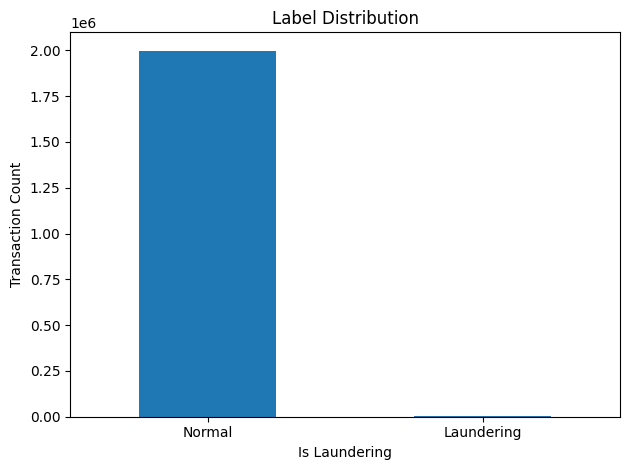

Saved: /home/acer/dev/aml-graph-dm/reports/figures/label_distribution.png


In [4]:
label_plot = df["is_laundering"].value_counts().sort_index()
ax = label_plot.plot(kind="bar")
ax.set_title("Label Distribution")
ax.set_xlabel("Is Laundering")
ax.set_ylabel("Transaction Count")
ax.set_xticklabels(["Normal", "Laundering"], rotation=0)
plt.tight_layout()

out_path = FIGURES_DIR / "label_distribution.png"
plt.savefig(out_path, dpi=150)
plt.show()

print("Saved:", out_path)

## 4. Transaction field overview

In [5]:
for col in ["payment_format", "payment_currency", "receiving_currency", "from_bank", "to_bank"]:
    if col in df.columns:
        print(f"\nTop values for {col}:")
        display(df[col].value_counts(dropna=False).head(10))


Top values for payment_format:


payment_format
Cheque          611741
Reinvestment    481056
Credit Card     422147
ACH             206713
Cash            164048
Wire             57933
Bitcoin          56362
Name: count, dtype: int64


Top values for payment_currency:


payment_currency
US Dollar      747766
Euro           461252
Swiss Franc     92639
Yuan            84116
Shekel          75771
Rupee           74865
UK Pound        70300
Yen             61579
Ruble           61210
Bitcoin         56349
Name: count, dtype: int64


Top values for receiving_currency:


receiving_currency
US Dollar      742724
Euro           462558
Swiss Franc     93636
Yuan            81768
Shekel          76679
Rupee           75438
UK Pound        70444
Ruble           61895
Yen             61893
Bitcoin         57034
Name: count, dtype: int64


Top values for from_bank:


from_bank
70     143255
10      28468
12      27664
1       21562
15      19170
220     18448
20      14389
3       13756
7       11299
211     10959
Name: count, dtype: int64


Top values for to_bank:


to_bank
10     16312
12     16218
15     14880
220    11904
1      11631
3       9837
7       8827
20      8519
28      8183
211     7934
Name: count, dtype: int64

## 5. Timestamp coverage

In [6]:
if "timestamp" in df.columns:
    print("Minimum timestamp:", df["timestamp"].min())
    print("Maximum timestamp:", df["timestamp"].max())
    print("Number of unique timestamps:", df["timestamp"].nunique())

    daily = (
        df.assign(date=df["timestamp"].dt.date)
        .groupby("date")
        .agg(
            rows=("is_laundering", "size"),
            laundering_count=("is_laundering", "sum"),
            laundering_rate=("is_laundering", "mean"),
        )
        .reset_index()
    )
    display(daily.head())
    display(daily.tail())

    daily.to_csv(TABLES_DIR / "daily_label_distribution_sample.csv", index=False)
    print("Saved:", TABLES_DIR / "daily_label_distribution_sample.csv")

Minimum timestamp: 2022-09-01 00:00:00
Maximum timestamp: 2022-09-10 13:24:00
Number of unique timestamps: 4243


,date,rows,laundering_count,laundering_rate
0,2022-09-01,1114921,322,0.000289
1,2022-09-02,754449,408,0.000541
2,2022-09-03,129805,309,0.002380
3,2022-09-04,331,187,0.564955
4,2022-09-05,200,116,0.580000


,date,rows,laundering_count,laundering_rate
5,2022-09-06,181,95,0.524862
6,2022-09-07,42,22,0.523810
7,2022-09-08,39,22,0.564103
8,2022-09-09,24,13,0.541667
9,2022-09-10,8,4,0.500000


Saved: /home/acer/dev/aml-graph-dm/reports/tables/daily_label_distribution_sample.csv


## 6. Label timeline audit by row chunks

In [7]:
timeline_path = TABLES_DIR / "hi_small_label_timeline.csv"

if timeline_path.exists():
    timeline = pd.read_csv(timeline_path)
    display(timeline)
else:
    print(
        "Timeline file not found. To create it, run:\n"
        "PYTHONPATH=. python scripts/audit_label_timeline.py --dataset HI-Small --chunksize 250000"
    )

,chunk_id,start_row,end_row,rows,normal_count,laundering_count,laundering_rate,min_timestamp,max_timestamp
0,1,0,249999,250000,249974,26,0.000104,2022-09-01 00:00:00,2022-09-04 15:48:00
1,2,250000,499999,250000,249833,167,0.000668,2022-09-01 00:00:00,2022-09-06 19:16:00
2,3,500000,749999,250000,249798,202,0.000808,2022-09-01 05:30:00,2022-09-08 01:16:00
3,4,750000,999999,250000,249820,180,0.000720,2022-09-01 13:00:00,2022-09-09 08:29:00
4,5,1000000,1249999,250000,249819,181,0.000724,2022-09-01 20:30:00,2022-09-09 17:14:00
5,6,1250000,1499999,250000,249871,129,0.000516,2022-09-02 03:30:00,2022-09-06 11:33:00
6,7,1500000,1749999,250000,249801,199,0.000796,2022-09-02 11:30:00,2022-09-06 16:16:00
7,8,1750000,1999999,250000,249586,414,0.001656,2022-09-02 20:00:00,2022-09-10 13:24:00
8,9,2000000,2249999,250000,249501,499,0.001996,2022-09-03 14:00:00,2022-09-11 03:21:00
9,10,2250000,2499999,250000,249669,331,0.001324,2022-09-04 19:30:00,2022-09-11 19:16:00


## 7. Sample graph statistics

In [8]:
# Build only a sample graph for quick exploratory graph statistics.
# Full graph feature engineering is handled in 02_feature_engineering.ipynb and src/features/.
G = build_sample_graph(df, max_edges=50_000)
graph_stats = graph_summary(G)

display(pd.DataFrame([graph_stats]))
pd.DataFrame([graph_stats]).to_csv(TABLES_DIR / "sample_graph_summary.csv", index=False)
print("Saved:", TABLES_DIR / "sample_graph_summary.csv")

,nodes,edges,density,weak_components,largest_weak_component,avg_in_degree,avg_out_degree
0,57051,48128,0.000015,44578,354,0.843596,0.843596


Saved: /home/acer/dev/aml-graph-dm/reports/tables/sample_graph_summary.csv


## Data-understanding notes for the report

Key observations to write in BAB IV:
- The data is highly imbalanced; laundering transactions are rare.
- Each transaction can be interpreted as a directed graph edge from sender account to receiver account.
- Because laundering patterns can appear as account behavior over time, temporal and graph-derived features are relevant.
- Chronological splitting is more realistic than random splitting because AML scoring should use past data to score later transactions.